In [88]:
# Libraries
import caveclient
import subprocess
import json
import numpy as np
import matplotlib.pyplot as plt
# Setup caveclient
client = caveclient.CAVEclient("wclee_mouse_spinalcord_cltmr", ) #server_address='https://global.daf-apis.com')

In [89]:
# Synapses df
#in_tag = client.materialize.query_table('excitatory_neuron_label')
exn_tag = client.materialize.query_table('spinalcord_neuron_clusters_2')
sensory_tag=client.materialize.query_table('sensory_neuron_label')

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.
Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


In [3]:
set(exn_tag['tag'])

{'adltmr_module',
 'cltmr_module',
 'noci_module',
 'np_module',
 'p1',
 'p2_cold',
 'p2_noci',
 'p2_poly',
 'r',
 'v1',
 'v2'}

In [4]:
set(sensory_tag['tag'])

{'C-COLD',
 'ab-ltmr',
 'ad-htmr',
 'adltmr',
 'c-htmr-p',
 'cltmr',
 'mrgd ',
 'sst '}

In [90]:
from tqdm import tqdm
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# Config
# --------------------------------------------------
SYNAPSE_TABLE = "synapses_version3"
SIZE_THRESHOLD = 20

out_dir = Path("sensory_exn_matrix")
out_dir.mkdir(parents=True, exist_ok=True)

exclude_sensory_tags = {}

sensory_order = [
    "C-COLD",
    "ad-htmr",
    "adltmr",
    "c-htmr-p",
    "cltmr",
    "mrgd",
    "sst",
    "ab-ltmr"
]

exn_order = [
    "p1",
    "p2_cold",
    "p2_noci",
    "p2_poly",
    "v1",
    "v2",
    "r",
    "noci_module",
    "np_module",
    "cltmr_module",
    "adltmr_module",
]

# --------------------------------------------------
# Prepare tag tables
# --------------------------------------------------
sensory_tag = sensory_tag.copy()
exn_tag = exn_tag.copy()

sensory_tag["pt_root_id"] = sensory_tag["pt_root_id"].astype(str)
exn_tag["pt_root_id"] = exn_tag["pt_root_id"].astype(str)

# IMPORTANT: remove trailing spaces from tags like "mrgd " and "sst "
sensory_tag["tag"] = sensory_tag["tag"].astype(str).str.strip()
exn_tag["tag"] = exn_tag["tag"].astype(str).str.strip()

print("All sensory labels after cleanup:")
print(sorted(sensory_tag["tag"].unique()))

sensory_tag_use = sensory_tag[
    (~sensory_tag["tag"].isin(exclude_sensory_tags))
    & (sensory_tag["tag"].isin(sensory_order))
].copy()

exn_tag_use = exn_tag[
    exn_tag["tag"].isin(exn_order)
].copy()

print("\nUsed sensory labels:")
print(sensory_tag_use["tag"].value_counts())
print("\nTotal sensory cells:", sensory_tag_use["pt_root_id"].nunique())

print("\nUsed ExN labels:")
print(exn_tag_use["tag"].value_counts())
print("\nTotal ExN cells:", exn_tag_use["pt_root_id"].nunique())

# --------------------------------------------------
# One label per cell
# --------------------------------------------------
sensory_cell_label = (
    sensory_tag_use
    .sort_values(["tag", "pt_root_id"])
    .drop_duplicates("pt_root_id")
    .set_index("pt_root_id")["tag"]
    .to_dict()
)

exn_cell_label = (
    exn_tag_use
    .sort_values(["tag", "pt_root_id"])
    .drop_duplicates("pt_root_id")
    .set_index("pt_root_id")["tag"]
    .to_dict()
)

sensory_ids = list(sensory_cell_label.keys())
exn_ids = set(exn_cell_label.keys())

# --------------------------------------------------
# Query synapses and collect cell-to-cell connections
# --------------------------------------------------
rows = []

for pre_id in tqdm(sensory_ids, desc="Query sensory neurons"):

    syn_df = client.materialize.query_table(
        SYNAPSE_TABLE,
        filter_equal_dict={"pre_pt_root_id": pre_id},
    )

    if syn_df is None or len(syn_df) == 0:
        continue

    syn_df = syn_df.copy()
    syn_df["pre_pt_root_id"] = syn_df["pre_pt_root_id"].astype(str)
    syn_df["post_pt_root_id"] = syn_df["post_pt_root_id"].astype(str)

    # exclude self synapses
    syn_df = syn_df[
        syn_df["pre_pt_root_id"] != syn_df["post_pt_root_id"]
    ]

    # keep only auto synapses with size >= 20
    syn_df = syn_df[
        syn_df["size"] >= SIZE_THRESHOLD
    ]

    # keep only postsynaptic ExNs
    syn_df = syn_df[
        syn_df["post_pt_root_id"].isin(exn_ids)
    ]

    if syn_df.empty:
        continue

    counts = syn_df["post_pt_root_id"].value_counts()

    for post_id, n_syn in counts.items():
        rows.append({
            "pre_pt_root_id": pre_id,
            "pre_type": sensory_cell_label[pre_id],
            "post_pt_root_id": post_id,
            "post_type": exn_cell_label[post_id],
            "synapses": int(n_syn),
        })

conn_cell_long = pd.DataFrame(rows)

# --------------------------------------------------
# Cell-to-cell matrix
# rows = individual sensory neurons
# cols = individual ExNs
# values = synapse counts
# --------------------------------------------------
if conn_cell_long.empty:
    cell_to_cell_matrix = pd.DataFrame()
else:
    cell_to_cell_matrix = (
        conn_cell_long
        .pivot_table(
            index="pre_pt_root_id",
            columns="post_pt_root_id",
            values="synapses",
            aggfunc="sum",
            fill_value=0,
        )
    )

# --------------------------------------------------
# Add missing rows/columns so all sensory and ExN cells appear
# --------------------------------------------------
sensory_ids_ordered = (
    sensory_tag_use
    .assign(tag_order=lambda x: x["tag"].map({k: i for i, k in enumerate(sensory_order)}))
    .sort_values(["tag_order", "pt_root_id"])
    ["pt_root_id"]
    .drop_duplicates()
    .tolist()
)

exn_ids_ordered = (
    exn_tag_use
    .assign(tag_order=lambda x: x["tag"].map({k: i for i, k in enumerate(exn_order)}))
    .sort_values(["tag_order", "pt_root_id"])
    ["pt_root_id"]
    .drop_duplicates()
    .tolist()
)

cell_to_cell_matrix = (
    cell_to_cell_matrix
    .reindex(index=sensory_ids_ordered, columns=exn_ids_ordered)
    .fillna(0)
    .astype(int)
)

# --------------------------------------------------
# Annotation tables
# --------------------------------------------------
pre_annotation = pd.DataFrame({
    "pt_root_id": sensory_ids_ordered,
    "sensory_type": [sensory_cell_label[x] for x in sensory_ids_ordered],
})

post_annotation = pd.DataFrame({
    "pt_root_id": exn_ids_ordered,
    "exn_type": [exn_cell_label[x] for x in exn_ids_ordered],
})

# --------------------------------------------------
# Save outputs
# --------------------------------------------------
cell_to_cell_matrix.to_csv(out_dir / "sensory_to_exn_cell_to_cell_matrix_0805.csv")
pre_annotation.to_csv(out_dir / "sensory_pre_labels_0805.csv", index=False)
post_annotation.to_csv(out_dir / "exn_post_labels_0805.csv", index=False)
conn_cell_long.to_csv(out_dir / "sensory_to_exn_cell_to_cell_long_0805.csv", index=False)

print("\nFinal matrix shape:", cell_to_cell_matrix.shape)
print("Saved to:", out_dir.resolve())

display(cell_to_cell_matrix)
display(pre_annotation)
display(post_annotation)

All sensory labels after cleanup:
['C-COLD', 'ab-ltmr', 'ad-htmr', 'adltmr', 'c-htmr-p', 'cltmr', 'mrgd', 'sst']

Used sensory labels:
tag
ab-ltmr     25
C-COLD      25
ad-htmr     22
c-htmr-p    20
mrgd        18
adltmr      18
sst         18
cltmr       16
Name: count, dtype: int64

Total sensory cells: 161

Used ExN labels:
tag
v1               41
v2               36
np_module        27
cltmr_module     24
r                24
p2_noci          16
p2_poly          15
adltmr_module    15
noci_module      10
p2_cold           9
p1                6
Name: count, dtype: int64

Total ExN cells: 223


Query sensory neurons: 100%|██████████| 161/161 [04:27<00:00,  1.66s/it]


Final matrix shape: (161, 223)
Saved to: /Users/wangchu/connectivity_analysis/matrix_for_modeling_figure6/sensory_exn_matrix


post_pt_root_id,720575940886574602,720575940888561868,720575940892250110,720575940893329739,720575940921478163,720575940964370854,720575940875863357,720575940882103072,720575940883198167,720575940884015788,...,720575940890900801,720575940895289006,720575940896732090,720575940902624978,720575940907584340,720575940917422227,720575940927248352,720575940937862061,720575940941124460,720575940948987670
pre_pt_root_id,,,,,,,,,,,,,,,,,,,,,
720575940851372659,0,0,0,0,0,0,0,5,1,0,...,0,0,0,0,0,0,0,0,0,0
720575940851375219,0,0,0,0,0,0,0,2,1,0,...,0,0,0,0,0,0,0,0,0,0
720575940872856946,0,0,0,0,0,0,0,10,16,0,...,0,0,0,0,0,0,0,0,0,0
720575940878947380,0,0,0,0,0,0,0,6,3,0,...,0,0,0,0,0,0,0,0,0,0
720575940881127565,0,0,0,0,0,0,0,0,3,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720575940917637910,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
720575940930944376,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
720575940932756628,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,pt_root_id,sensory_type
0,720575940851372659,C-COLD
1,720575940851375219,C-COLD
2,720575940872856946,C-COLD
3,720575940878947380,C-COLD
4,720575940881127565,C-COLD
...,...,...
156,720575940917637910,ab-ltmr
157,720575940930944376,ab-ltmr
158,720575940932756628,ab-ltmr
159,720575940933768470,ab-ltmr


,pt_root_id,exn_type
0,720575940886574602,p1
1,720575940888561868,p1
2,720575940892250110,p1
3,720575940893329739,p1
4,720575940921478163,p1
...,...,...
218,720575940917422227,adltmr_module
219,720575940927248352,adltmr_module
220,720575940937862061,adltmr_module
221,720575940941124460,adltmr_module


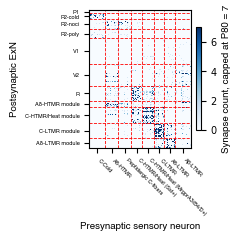

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# Config
# --------------------------------------------------
out_dir = Path("sensory_exn_matrix")
out_dir.mkdir(parents=True, exist_ok=True)

SAVE_FIG = True
FIG_NAME = "sensory_to_exn_cell_to_cell_matrix_post_by_pre_0805.svg"

CAP_MODE = "percentile"
CAP_PERCENTILE = 80

sensory_order = [
    "C-COLD",
    "ad-htmr",
    "c-htmr-p",
    "sst",
    "mrgd",
    "cltmr",
    "adltmr",
    "ab-ltmr"
]

exn_order = [
    "p1",
    "p2_cold",
    "p2_noci",
    "p2_poly",
    "v1",
    "v2",
    "r",
    "noci_module",
    "np_module",
    "cltmr_module",
    "adltmr_module",
]

SENSORY_LABEL_MAP = {
    "ad-htmr": "Aδ-HTMR",
    "C-COLD": "C-Cold",
    "sst": "C-HTMR/Heat (Sst+)",
    "mrgd": "C-HTMR/Heat (MrgprA3/B4/D+)",
    "c-htmr-p": "Peptidergic C-fibers",
    "adltmr": "Aδ-LTMR",
    "cltmr": "C-LTMR",
    "ab-ltmr":"Aβ-LTMR"
}

EXN_LABEL_MAP = {
    "p1": "P1",
    "p2_cold": "P2-cold",
    "p2_noci": "P2-noci",
    "p2_poly": "P2-poly",
    "v1": "V1",
    "v2": "V2",
    "r": "R",
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

# --------------------------------------------------
# Prepare annotations
# --------------------------------------------------
pre_ann = pre_annotation.copy()
post_ann = post_annotation.copy()

pre_ann["pt_root_id"] = pre_ann["pt_root_id"].astype(str)
post_ann["pt_root_id"] = post_ann["pt_root_id"].astype(str)

pre_ann["sensory_type"] = pre_ann["sensory_type"].astype(str)
post_ann["exn_type"] = post_ann["exn_type"].astype(str)

pre_type_map = pre_ann.set_index("pt_root_id")["sensory_type"]
post_type_map = post_ann.set_index("pt_root_id")["exn_type"]

# --------------------------------------------------
# Build full post x pre matrix
# --------------------------------------------------
A = cell_to_cell_matrix.copy()
A.index = A.index.astype(str)
A.columns = A.columns.astype(str)

# current matrix: rows = pre sensory, cols = post ExN
# transpose to: rows = post ExN, cols = pre sensory
A = A.T

# force all annotated cells to appear, including zero-connection cells
A = (
    A.reindex(
        index=post_ann["pt_root_id"].tolist(),
        columns=pre_ann["pt_root_id"].tolist(),
    )
    .fillna(0)
    .astype(int)
)

def ordered_categorical(series, order):
    s = series.fillna("unknown").astype(str)
    cats, seen = [], set()

    for c in order:
        if c not in seen:
            cats.append(c)
            seen.add(c)

    for c in s.unique():
        if c not in seen:
            cats.append(c)
            seen.add(c)

    return pd.Categorical(s, categories=cats, ordered=True)

def compute_sorted_ids_and_bounds(ids, tag_map, cluster_order):
    ids = pd.Index(ids).astype(str)
    tags = tag_map.reindex(ids).fillna("unknown")

    order_df = pd.DataFrame({
        "id": ids,
        "tag": ordered_categorical(tags, cluster_order),
    })

    order_df = (
        order_df
        .sort_values(["tag", "id"], kind="mergesort")
        .reset_index(drop=True)
    )

    sorted_ids = order_df["id"].tolist()

    starts, ends, labels = [], [], []
    for tag, grp in order_df.groupby("tag", sort=False, observed=True):
        starts.append(grp.index[0])
        ends.append(grp.index[-1] + 1)
        labels.append(str(tag))

    centers = [(s + e - 1) / 2 for s, e in zip(starts, ends)]
    boundaries = [e - 0.5 for e in ends[:-1]]

    return sorted_ids, labels, centers, boundaries

# --------------------------------------------------
# Sort rows = post ExNs, columns = pre sensory neurons
# --------------------------------------------------
row_sorted, row_labels, row_centers, row_boundaries = compute_sorted_ids_and_bounds(
    A.index,
    post_type_map,
    exn_order,
)

col_sorted, col_labels, col_centers, col_boundaries = compute_sorted_ids_and_bounds(
    A.columns,
    pre_type_map,
    sensory_order,
)

A_sorted = (
    A.reindex(index=row_sorted, columns=col_sorted)
     .fillna(0)
     .astype(int)
)

# --------------------------------------------------
# Cap values for visualization
# --------------------------------------------------
vals = A_sorted.values
pos = vals[np.isfinite(vals) & (vals > 0)]

if CAP_MODE == "percentile":
    if pos.size > 0:
        vmax = float(np.percentile(pos, CAP_PERCENTILE))
        A_vis = A_sorted.clip(upper=vmax)
        cbar_label = f"Synapse count, capped at P{CAP_PERCENTILE} = {vmax:.3g}"
    else:
        vmax = 1
        A_vis = A_sorted
        cbar_label = "Synapse count"
elif CAP_MODE == "none":
    vmax = None
    A_vis = A_sorted
    cbar_label = "Synapse count"
else:
    raise ValueError("CAP_MODE must be 'percentile' or 'none'.")

# --------------------------------------------------
# Plot
# --------------------------------------------------
cm = 1 / 2.54
fig, ax = plt.subplots(figsize=(6 * cm, 6 * cm))

im = ax.imshow(
    A_vis.values,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=vmax,
    interpolation="nearest",
)

row_labels_display = [EXN_LABEL_MAP.get(x, x) for x in row_labels]
col_labels_display = [SENSORY_LABEL_MAP.get(x, x) for x in col_labels]

ax.set_xticks(col_centers)
ax.set_xticklabels(
    col_labels_display,
    rotation=-45,
    ha="left",
    fontsize=4,
    fontname="Helvetica",
)

ax.set_yticks(row_centers)
ax.set_yticklabels(
    row_labels_display,
    fontsize=4,
    fontname="Helvetica",
)

for x in col_boundaries:
    ax.axvline(x, linestyle="--", color="red", linewidth=0.6)

for y in row_boundaries:
    ax.axhline(y, linestyle="--", color="red", linewidth=0.6)

ax.set_xlabel("Presynaptic sensory neuron", fontsize=7, fontname="Helvetica")
ax.set_ylabel("Postsynaptic ExN", fontsize=7, fontname="Helvetica")

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(cbar_label, fontsize=7, fontname="Helvetica")
cbar.ax.tick_params(labelsize=7)

plt.tight_layout()

if SAVE_FIG:
    plt.savefig(out_dir / FIG_NAME, bbox_inches="tight")

plt.show()

In [7]:
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# Config
# --------------------------------------------------
out_dir = Path("sensory_exn_matrix")
out_dir.mkdir(parents=True, exist_ok=True)

exclude_sensory_tags = {"ab-ltmr"}

sensory_order = [
    "C-COLD",
    "ad-htmr",
    "adltmr",
    "c-htmr-p",
    "cltmr",
    "mrgd",
    "sst",
]

exn_order = [
    "p1",
    "p2_cold",
    "p2_noci",
    "p2_poly",
    "v1",
    "v2",
    "r",
    "noci_module",
    "np_module",
    "cltmr_module",
    "adltmr_module",
]

SENSORY_LABEL_MAP = {
    "ad-htmr": "Aδ-HTMR",
    "C-COLD": "C-Cold",
    "sst": "C-HTMR/Heat (Sst+)",
    "mrgd": "C-HTMR/Heat (MrgprA3/B4/D+)",
    "c-htmr-p": "Peptidergic C-Nociceptor",
    "adltmr": "Aδ-LTMR",
    "cltmr": "C-LTMR",
}

EXN_LABEL_MAP = {
    "p1": "P1",
    "p2_cold": "P2-cold",
    "p2_noci": "P2-noci",
    "p2_poly": "P2-poly",
    "v1": "V1",
    "v2": "V2",
    "r": "R",
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

# --------------------------------------------------
# Clean labels
# --------------------------------------------------
sensory_clean = sensory_tag.copy()
exn_clean = exn_tag.copy()

sensory_clean["pt_root_id"] = sensory_clean["pt_root_id"].astype(str)
exn_clean["pt_root_id"] = exn_clean["pt_root_id"].astype(str)

sensory_clean["tag"] = sensory_clean["tag"].astype(str).str.strip()
exn_clean["tag"] = exn_clean["tag"].astype(str).str.strip()

# --------------------------------------------------
# Build pre and post tables
# --------------------------------------------------
pre_cells = (
    sensory_clean
    .loc[
        (~sensory_clean["tag"].isin(exclude_sensory_tags))
        & (sensory_clean["tag"].isin(sensory_order)),
        ["pt_root_id", "tag"]
    ]
    .drop_duplicates("pt_root_id")
    .rename(columns={"pt_root_id": "pre_id", "tag": "pre_raw_label"})
)

post_cells = (
    exn_clean
    .loc[
        exn_clean["tag"].isin(exn_order),
        ["pt_root_id", "tag"]
    ]
    .drop_duplicates("pt_root_id")
    .rename(columns={"pt_root_id": "post_id", "tag": "post_raw_label"})
)

pre_cells["pre_label"] = pre_cells["pre_raw_label"].map(SENSORY_LABEL_MAP).fillna(pre_cells["pre_raw_label"])
post_cells["post_label"] = post_cells["post_raw_label"].map(EXN_LABEL_MAP).fillna(post_cells["post_raw_label"])

# optional: sort by biological order, then ID
pre_cells["pre_order"] = pre_cells["pre_raw_label"].map({k: i for i, k in enumerate(sensory_order)})
post_cells["post_order"] = post_cells["post_raw_label"].map({k: i for i, k in enumerate(exn_order)})

pre_cells = pre_cells.sort_values(["pre_order", "pre_id"]).reset_index(drop=True)
post_cells = post_cells.sort_values(["post_order", "post_id"]).reset_index(drop=True)

# --------------------------------------------------
# All possible pre-post pairs
# --------------------------------------------------
all_pairs = (
    pre_cells[["pre_id", "pre_label"]]
    .merge(
        post_cells[["post_id", "post_label"]],
        how="cross"
    )
)

# reorder columns
all_pairs = all_pairs[
    ["pre_id", "post_id", "pre_label", "post_label"]
]

# --------------------------------------------------
# Save
# --------------------------------------------------
all_pairs.to_csv(
    out_dir / "all_possible_sensory_exn_pairs.csv",
    index=False,
)

print("Number of pre cells:", pre_cells["pre_id"].nunique())
print("Number of post cells:", post_cells["post_id"].nunique())
print("Number of all possible pairs:", len(all_pairs))
print("Saved to:", (out_dir / "all_possible_sensory_exn_pairs.csv").resolve())

display(all_pairs)

Number of pre cells: 136
Number of post cells: 223
Number of all possible pairs: 30328
Saved to: /Users/wangchu/connectivity_analysis/matrix_for_modeling_figure6/sensory_exn_matrix/all_possible_sensory_exn_pairs.csv


,pre_id,post_id,pre_label,post_label
0,720575940851372659,720575940886574602,C-Cold,P1
1,720575940851372659,720575940888561868,C-Cold,P1
2,720575940851372659,720575940892250110,C-Cold,P1
3,720575940851372659,720575940893329739,C-Cold,P1
4,720575940851372659,720575940921478163,C-Cold,P1
...,...,...,...,...
30323,720575940930873976,720575940917422227,C-HTMR/Heat (Sst+),Aδ-LTMR module
30324,720575940930873976,720575940927248352,C-HTMR/Heat (Sst+),Aδ-LTMR module
30325,720575940930873976,720575940937862061,C-HTMR/Heat (Sst+),Aδ-LTMR module
30326,720575940930873976,720575940941124460,C-HTMR/Heat (Sst+),Aδ-LTMR module


In [2]:
# part two following code is for plotting the grid bubble plot used for weight sensory synapse connectivity, it does not require
# runing previous code
import pandas as pd
import numpy as np
from pathlib import Path


# --------------------------------------------------
# Paths
# --------------------------------------------------

connectivity_file = Path(
    "sensory_exn_matrix/"
    "sensory_to_exn_cell_to_cell_matrix.csv"
)

overlap_file = Path(
    "sensory_exn_matrix/"
    "all_possible_sensory_exn_pairs_with_overlap.csv"
)


# --------------------------------------------------
# 1) Load connectivity matrix
# --------------------------------------------------

A = pd.read_csv(
    connectivity_file,
    index_col=0
)

A.index = A.index.astype(str)
A.columns = A.columns.astype(str)

A = A.apply(
    pd.to_numeric,
    errors="coerce"
)

print("Connectivity matrix:")
print(A.shape)
print("Pre IDs:", len(A.index))
print("Post IDs:", len(A.columns))


# --------------------------------------------------
# 2) Load overlap long table
# --------------------------------------------------

overlap_long = pd.read_csv(
    overlap_file
)

overlap_long["pre_id"] = (
    overlap_long["pre_id"]
    .astype(str)
)

overlap_long["post_id"] = (
    overlap_long["post_id"]
    .astype(str)
)


print("\nOverlap table:")
print(overlap_long.shape)

print(
    "Unique pre IDs:",
    overlap_long["pre_id"].nunique()
)

print(
    "Unique post IDs:",
    overlap_long["post_id"].nunique()
)


# --------------------------------------------------
# 3) Build overlap matrix
# --------------------------------------------------

O = overlap_long.pivot_table(
    index="pre_id",
    columns="post_id",
    values="sensory_axon_exn_dendrite_overlap_um",
    aggfunc="first",
)


O.index = O.index.astype(str)
O.columns = O.columns.astype(str)


print("\nOverlap matrix:")
print(O.shape)


# --------------------------------------------------
# 4) Check ID matching
# --------------------------------------------------

A_pre = set(A.index)
A_post = set(A.columns)

O_pre = set(O.index)
O_post = set(O.columns)


print("\nPre ID matching:")
print("Connectivity only:",
      len(A_pre - O_pre))

print("Overlap only:",
      len(O_pre - A_pre))


print("\nPost ID matching:")
print("Connectivity only:",
      len(A_post - O_post))

print("Overlap only:",
      len(O_post - A_post))


# --------------------------------------------------
# 5) Align overlap to connectivity
# --------------------------------------------------

O_aligned = O.reindex(
    index=A.index,
    columns=A.columns
)


print("\nAligned overlap:")
print(O_aligned.shape)


# --------------------------------------------------
# 6) Check missing overlap values
# --------------------------------------------------

missing = O_aligned.isna().sum().sum()

print(
    "\nMissing overlap entries:",
    missing,
    "/",
    A.shape[0] * A.shape[1]
)


# --------------------------------------------------
# 7) Save objects for plotting
# --------------------------------------------------

print("\nReady:")
print("A = connectivity matrix")
print("O_aligned = overlap matrix")

Connectivity matrix:
(136, 223)
Pre IDs: 136
Post IDs: 223

Overlap table:
(30328, 11)
Unique pre IDs: 136
Unique post IDs: 223

Overlap matrix:
(136, 223)

Pre ID matching:
Connectivity only: 0
Overlap only: 0

Post ID matching:
Connectivity only: 0
Overlap only: 0

Aligned overlap:
(136, 223)

Missing overlap entries: 55 / 30328

Ready:
A = connectivity matrix
O_aligned = overlap matrix


Overlap color cap: P95 = 591.22 µm


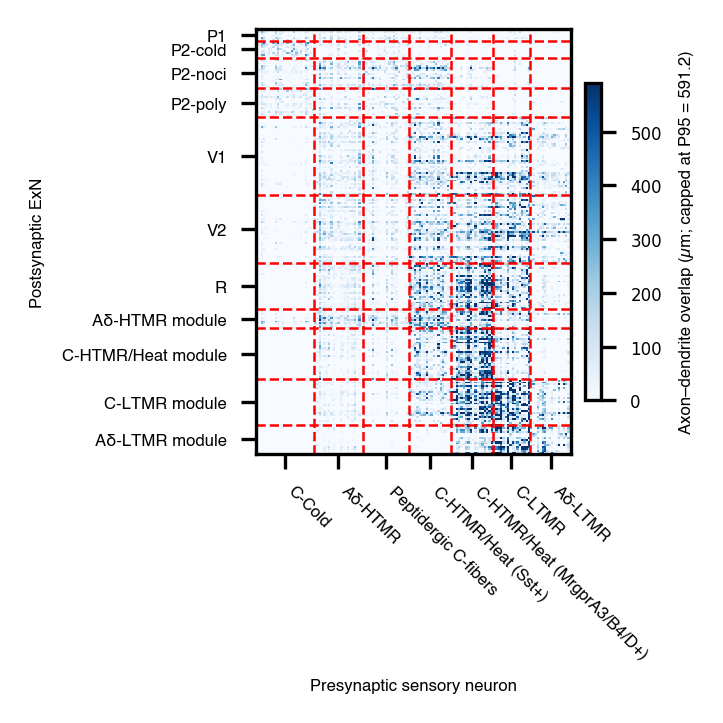

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ==================================================
# Configuration
# ==================================================

SAVE_FIG = True

OUTPUT_DIR = Path("sensory_exn_matrix")
OUTPUT_NAME = "sensory_to_exn_overlap_matrix_0805.svg"

FIG_SIZE_CM = (6, 6)

CAP_PERCENTILE = 95

# If True, missing overlap measurements are displayed as zero.
# If False, they remain missing and appear white.
FILL_MISSING_WITH_ZERO = False


# ==================================================
# Cell-type display order
# ==================================================

sensory_order = [
    "C-Cold",
    "Aδ-HTMR",
    "Peptidergic C-Nociceptor",
    "C-HTMR/Heat (Sst+)",
    "C-HTMR/Heat (MrgprA3/B4/D+)",
    "C-LTMR",
    "Aδ-LTMR",
    "Aβ-LTMR",
]

exn_order = [
    "P1",
    "P2-cold",
    "P2-noci",
    "P2-poly",
    "V1",
    "V2",
    "R",
    "Aδ-HTMR module",
    "C-HTMR/Heat module",
    "C-LTMR module",
    "Aδ-LTMR module",
]


# ==================================================
# Optional display remapping
# ==================================================
# Keys should match the labels in overlap_long.

SENSORY_LABEL_MAP = {
    "C-Cold": "C-Cold",
    "Aδ-HTMR": "Aδ-HTMR",
    "Peptidergic C-Nociceptor": "Peptidergic C-fibers",
    "C-HTMR/Heat (Sst+)": "C-HTMR/Heat (Sst+)",
    "C-HTMR/Heat (MrgprA3/B4/D+)":
        "C-HTMR/Heat (MrgprA3/B4/D+)",
    "C-LTMR": "C-LTMR",
    "Aδ-LTMR": "Aδ-LTMR",
    "Aβ-LTMR": "Aβ-LTMR",
}

EXN_LABEL_MAP = {
    "P1": "P1",
    "P2-cold": "P2-cold",
    "P2-noci": "P2-noci",
    "P2-poly": "P2-poly",
    "V1": "V1",
    "V2": "V2",
    "R": "R",
    "Aδ-HTMR module": "Aδ-HTMR module",
    "C-HTMR/Heat module": "C-HTMR/Heat module",
    "C-LTMR module": "C-LTMR module",
    "Aδ-LTMR module": "Aδ-LTMR module",
}


# ==================================================
# Build neuron ID → cell-type maps
# ==================================================

sensory_label_map = (
    overlap_long[["pre_id", "pre_label"]]
    .drop_duplicates(subset="pre_id")
    .set_index("pre_id")["pre_label"]
)

exn_label_map = (
    overlap_long[["post_id", "post_label"]]
    .drop_duplicates(subset="post_id")
    .set_index("post_id")["post_label"]
)

sensory_label_map.index = sensory_label_map.index.astype(str)
exn_label_map.index = exn_label_map.index.astype(str)


# ==================================================
# Sorting function
# ==================================================

def compute_sorted_ids_and_bounds(ids, label_map, cluster_order):

    ids = pd.Index(ids).astype(str)

    labels = (
        label_map
        .reindex(ids)
        .fillna("unknown")
        .astype(str)
    )

    # Include unexpected labels after the specified order.
    complete_order = list(cluster_order)

    for label in labels.unique():
        if label not in complete_order:
            complete_order.append(label)

    order_df = pd.DataFrame({
        "id": ids,
        "label": pd.Categorical(
            labels,
            categories=complete_order,
            ordered=True,
        ),
    })

    order_df = (
        order_df
        .sort_values(
            ["label", "id"],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    sorted_ids = order_df["id"].tolist()

    starts = []
    ends = []
    group_labels = []

    for label, group in order_df.groupby(
        "label",
        observed=True,
        sort=False,
    ):
        starts.append(group.index[0])
        ends.append(group.index[-1] + 1)
        group_labels.append(str(label))

    centers = [
        (start + end - 1) / 2
        for start, end in zip(starts, ends)
    ]

    boundaries = [
        end - 0.5
        for end in ends[:-1]
    ]

    return sorted_ids, group_labels, centers, boundaries


# ==================================================
# Prepare overlap matrix
# ==================================================

# O_aligned currently has:
# rows    = presynaptic sensory neurons
# columns = postsynaptic ExNs
#
# Transpose it so the plot has:
# rows    = postsynaptic ExNs
# columns = presynaptic sensory neurons

O_plot = O_aligned.copy()
O_plot.index = O_plot.index.astype(str)
O_plot.columns = O_plot.columns.astype(str)
O_plot = O_plot.T


# ==================================================
# Sort neurons by cell type
# ==================================================

row_sorted, row_labels, row_centers, row_boundaries = (
    compute_sorted_ids_and_bounds(
        O_plot.index,
        exn_label_map,
        exn_order,
    )
)

col_sorted, col_labels, col_centers, col_boundaries = (
    compute_sorted_ids_and_bounds(
        O_plot.columns,
        sensory_label_map,
        sensory_order,
    )
)

O_sorted = O_plot.reindex(
    index=row_sorted,
    columns=col_sorted,
)

if FILL_MISSING_WITH_ZERO:
    O_sorted = O_sorted.fillna(0)


# ==================================================
# Calculate visualization cap
# ==================================================

values = O_sorted.to_numpy(dtype=float)

positive_values = values[
    np.isfinite(values) & (values > 0)
]

if positive_values.size > 0:

    vmax_overlap = float(
        np.percentile(
            positive_values,
            CAP_PERCENTILE,
        )
    )

    if vmax_overlap <= 0:
        vmax_overlap = float(np.nanmax(positive_values))

else:
    vmax_overlap = 1.0

O_vis = O_sorted.clip(
    lower=0,
    upper=vmax_overlap,
)


print(
    f"Overlap color cap: P{CAP_PERCENTILE} "
    f"= {vmax_overlap:.2f} µm"
)


# ==================================================
# Plot
# ==================================================

cm = 1 / 2.54

fig, ax = plt.subplots(
    figsize=(
        FIG_SIZE_CM[0] * cm,
        FIG_SIZE_CM[1] * cm,
    ),
    dpi=300,
)

# Make missing values white.
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("white")

im = ax.imshow(
    O_vis.to_numpy(dtype=float),
    aspect="auto",
    cmap=cmap,
    vmin=0,
    vmax=vmax_overlap,
    interpolation="nearest",
)


# ==================================================
# Cell-type labels
# ==================================================

row_labels_display = [
    EXN_LABEL_MAP.get(label, label)
    for label in row_labels
]

col_labels_display = [
    SENSORY_LABEL_MAP.get(label, label)
    for label in col_labels
]

ax.set_xticks(col_centers)

ax.set_xticklabels(
    col_labels_display,
    rotation=-45,
    ha="left",
    fontsize=4,
    fontname="Helvetica",
)

ax.set_yticks(row_centers)

ax.set_yticklabels(
    row_labels_display,
    fontsize=4,
    fontname="Helvetica",
)


# ==================================================
# Cell-type boundaries
# ==================================================

for x in col_boundaries:
    ax.axvline(
        x,
        linestyle="--",
        color="red",
        linewidth=0.6,
    )

for y in row_boundaries:
    ax.axhline(
        y,
        linestyle="--",
        color="red",
        linewidth=0.6,
    )


# ==================================================
# Axis labels and colorbar
# ==================================================

ax.set_xlabel(
    "Presynaptic sensory neuron",
    fontsize=4,
    fontname="Helvetica",
)

ax.set_ylabel(
    "Postsynaptic ExN",
    fontsize=4,
    fontname="Helvetica",
)

cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

cbar.set_label(
    (
        "Axon–dendrite overlap "
        f"(µm; capped at P{CAP_PERCENTILE} "
        f"= {vmax_overlap:.1f})"
    ),
    fontsize=4,
    fontname="Helvetica",
)

cbar.ax.tick_params(labelsize=4)

plt.tight_layout()


# ==================================================
# Optional save
# ==================================================

if SAVE_FIG:

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    plt.savefig(
        OUTPUT_DIR / OUTPUT_NAME,
        bbox_inches="tight",
    )

plt.show()

In [85]:
# --------------------------------------------------
# Build neuron ID -> label maps
# --------------------------------------------------

sensory_label_map = (
    overlap_long[["pre_id", "pre_label"]]
    .drop_duplicates()
    .set_index("pre_id")["pre_label"]
)

exn_label_map = (
    overlap_long[["post_id", "post_label"]]
    .drop_duplicates()
    .set_index("post_id")["post_label"]
)


# check
print(sensory_label_map.shape)
print(exn_label_map.shape)

print(sensory_label_map.value_counts())
print(exn_label_map.value_counts())

(136,)
(223,)
pre_label
C-Cold                         25
Aδ-HTMR                        21
Peptidergic C-Nociceptor       20
Aδ-LTMR                        18
C-HTMR/Heat (MrgprA3/B4/D+)    18
C-HTMR/Heat (Sst+)             18
C-LTMR                         16
Name: count, dtype: int64
post_label
V1                    41
V2                    36
C-HTMR/Heat module    27
R                     24
C-LTMR module         24
P2-noci               16
P2-poly               15
Aδ-LTMR module        15
Aδ-HTMR module        10
P2-cold                9
P1                     6
Name: count, dtype: int64


In [22]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


mpl.rcParams.update({
    "font.size": 5,
    "axes.titlesize": 5,
    "axes.labelsize": 5,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 5,
})


def _area_scaled_sizes(vals, max_area_pts2=400, size_vmax=None):

    vals = np.asarray(vals, float)

    if size_vmax is None:
        size_vmax = np.nanmax(vals)

    if size_vmax <= 0:
        return np.zeros_like(vals)

    return vals / size_vmax * max_area_pts2

def add_size_legend(
    ax,
    size_vmax,
    ticks_abs,
    max_diam_pts=7,
):

    handles = []

    for v in ticks_abs:

        area = (
            v / size_vmax
        ) * (max_diam_pts ** 2)

        h = ax.scatter(
            [],
            [],
            s=area,
            color="#0b3c78",
            edgecolors="none",
        )

        handles.append(h)


    legend = ax.legend(
        handles,
        [f"{v:.2f}" for v in ticks_abs],
        title="Avg Syn count",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=True,
        borderpad=0.3,
        labelspacing=0.8,
        handletextpad=0.5,
        fontsize=5,
        title_fontsize=5,
    )

    return legend

def bubble_grid(
    size_df,
    color_df,
    pre_order,
    post_order,
    title="",
    cmap="Blues",
    max_diam_pts=7,
    fig_cm=(4,5),
    color_cap_percentile=95,
    size_vmax=None,
    size_legend_ticks_abs=None,
    pre_label_map=None,
    post_label_map=None,
    save_svg_path=None,
):

    size_df = size_df.reindex(
        index=pre_order,
        columns=post_order
    )

    color_df = color_df.reindex(
        index=pre_order,
        columns=post_order
    )


    xs = []
    ys = []
    sizes = []
    colors = []


    for i, pre in enumerate(pre_order):

        for j, post in enumerate(post_order):

            s = size_df.loc[pre, post]
            c = color_df.loc[pre, post]

            if np.isfinite(s) and np.isfinite(c):

                xs.append(i)
                ys.append(j)
                sizes.append(s)
                colors.append(c)


    xs = np.array(xs)
    ys = np.array(ys)

    sizes = np.array(sizes)
    colors = np.array(colors)


    # -------------------------
    # color normalization
    # -------------------------

    # fixed color scale for sensory→ExN figure
    vmax_color = 0.14

    norm = mpl.colors.Normalize(
        vmin=0,
        vmax=vmax_color
    )


    fig, ax = plt.subplots(
        figsize=(
            fig_cm[0]/2.54,
            fig_cm[1]/2.54
        ),
        dpi=300
    )


    # -------------------------
    # bubble size
    # -------------------------

    if size_vmax is None:
        size_vmax = np.nanmax(sizes)


    bubble_area = _area_scaled_sizes(
        sizes,
        max_area_pts2=max_diam_pts**2,
        size_vmax=size_vmax
    )


    sc = ax.scatter(
        xs,
        ys,
        s=bubble_area,
        c=colors,
        cmap=cmap,
        norm=norm,
        edgecolors="none",
    )
    
    add_size_legend(
    ax,
    size_vmax=size_vmax,
    ticks_abs=[
        1,
        2,
        4,
        8,
    ],
    max_diam_pts=max_diam_pts,
    )


    # -------------------------
    # axes
    # -------------------------

    ax.set_xticks(
        np.arange(len(pre_order))
    )

    ax.set_yticks(
        np.arange(len(post_order))
    )


    ax.set_xticklabels(
        [
            (pre_label_map or {}).get(x,x)
            for x in pre_order
        ],
        rotation=-45,
        ha="left",
    )


    ax.set_yticklabels(
        [
            (post_label_map or {}).get(x,x)
            for x in post_order
        ]
    )


    ax.set_xlim(
        -0.5,
        len(pre_order)-0.5
    )

    ax.set_ylim(
        len(post_order)-0.5,
        -0.5
    )


    ax.grid(
        linestyle=":",
        linewidth=0.3
    )


    ax.set_title(title)


    # -------------------------
    # color bar
    # -------------------------
    cbar = fig.colorbar(
        sc,
        ax=ax,
        fraction=0.03,
        pad=0.08,
    )

    cbar.set_ticks(
        [
          0.00,
          0.035,
          0.07,
          0.105,
          0.14,
        ]
    )

    cbar.ax.yaxis.set_major_formatter(
        FuncFormatter(
            lambda x, pos: f"{x:.2f}"
        )
    )

    cbar.set_label(
        "Avg. normalized syn. density\n"
        "(synapses / 10 µm overlap)",
        fontsize=5,
        labelpad=4,
    )

    cbar.ax.tick_params(
        labelsize=5
    )


    if save_svg_path:

        plt.savefig(
            save_svg_path,
            dpi=300,
            bbox_inches="tight"
        )


    plt.show()

In [23]:
import numpy as np
import pandas as pd


# ----------------------------
# orders
# ----------------------------

pre_order = [
    "C-Cold",
    "Aδ-HTMR",
    "Peptidergic C-Nociceptor",
    "C-HTMR/Heat (Sst+)",
    "C-HTMR/Heat (MrgprA3/B4/D+)",
    "C-LTMR",
    "Aδ-LTMR",
    
    
    
]


post_order = [
    "P1",
    "P2-cold",
    "P2-noci",
    "P2-poly",
    "V1",
    "V2",
    "R",
    "Aδ-HTMR module",
    "C-HTMR/Heat module",
    "C-LTMR module",
    "Aδ-LTMR module",
    
]


# ----------------------------
# label maps
# ----------------------------

pre_map = sensory_label_map.astype(str)
post_map = exn_label_map.astype(str)


ids_by_pre = {
    x:
    pre_map[
        pre_map == x
    ].index.intersection(A.index.astype(str))
    for x in pre_order
}


ids_by_post = {
    x:
    post_map[
        post_map == x
    ].index.intersection(A.columns.astype(str))
    for x in post_order
}


# ----------------------------
# output matrices
# ----------------------------

density_overlap_only = pd.DataFrame(
    np.nan,
    index=pre_order,
    columns=post_order
)


avg_syn_overlap_pair = pd.DataFrame(
    np.nan,
    index=pre_order,
    columns=post_order
)



# ----------------------------
# calculate
# ----------------------------

for pre in pre_order:

    rows = list(ids_by_pre[pre])


    for post in post_order:

        cols = list(ids_by_post[post])


        if len(rows)==0 or len(cols)==0:
            continue


        blockA = A.loc[
            rows, cols
        ].to_numpy(float)


        blockO = O_aligned.loc[
            rows, cols
        ].to_numpy(float)



        validA = np.isfinite(blockA)
        validO = np.isfinite(blockO)


        # IMPORTANT:
        # only pairs with overlap

        overlap_mask = (
            validO &
            (blockO > 0)
        )


        total_syn = np.nansum(
            np.where(
                validA,
                blockA,
                0
            )
        )


        n_overlap_pairs = (
            overlap_mask.sum()
        )


        # --------------------------
        # color:
        # synapses / µm overlap
        # only overlap pairs
        # --------------------------

        density = np.divide(
            blockA,
            blockO,
            where=overlap_mask
        )


        density = np.where(
            overlap_mask &
            np.isfinite(density),
            density,
            np.nan
        )


        if np.isfinite(density).any():

            density_overlap_only.loc[
                pre,
                post
            ] = np.nanmean(density)



        # --------------------------
        # size:
        # average synapses per
        # overlapping pair
        # --------------------------

        if n_overlap_pairs > 0:

            avg_syn_overlap_pair.loc[
                pre,
                post
            ] = (
                total_syn /
                n_overlap_pairs
            )



# Convert density to synapses / 10 µm
density_overlap_only_plot = (
    density_overlap_only * 10
)

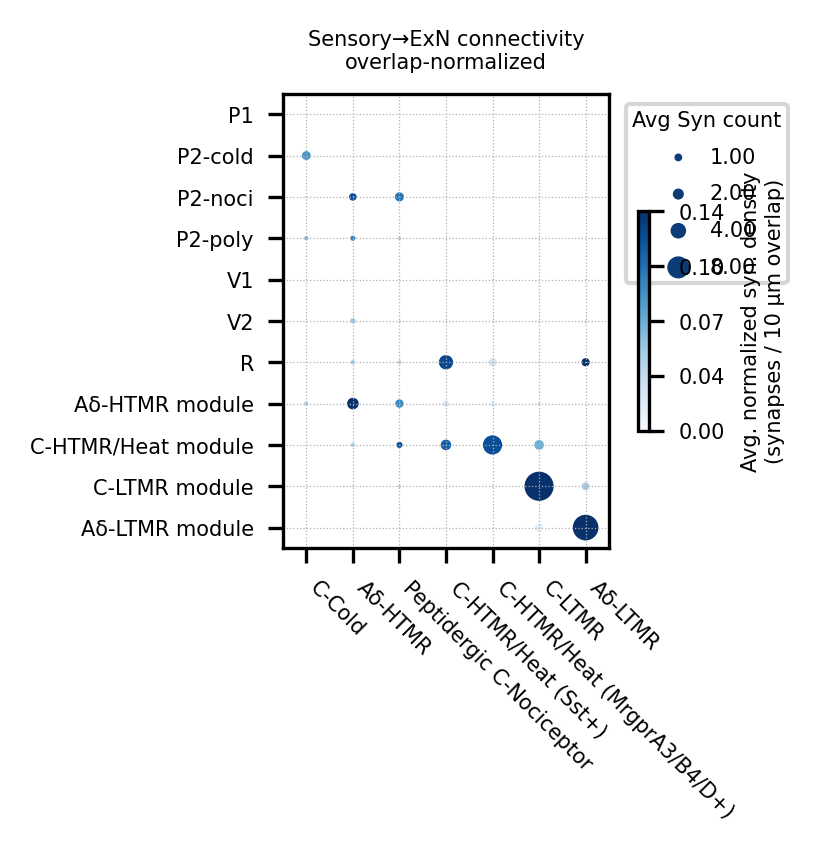

In [25]:
bubble_grid(
    size_df=avg_syn_overlap_pair,
    color_df=density_overlap_only_plot,

    pre_order=pre_order,
    post_order=post_order,

    title=(
        "Sensory→ExN connectivity\n"
        "overlap-normalized"
    ),

    cmap="Blues",

    max_diam_pts=7,

    fig_cm=(4,5),

    color_cap_percentile=95,

    size_vmax=np.nanmax(
        avg_syn_overlap_pair.to_numpy()
    ),

    pre_label_map=None,
    post_label_map=None,

    save_svg_path=
    "sensory_exn_overlap_normalized_bubble.svg"
)

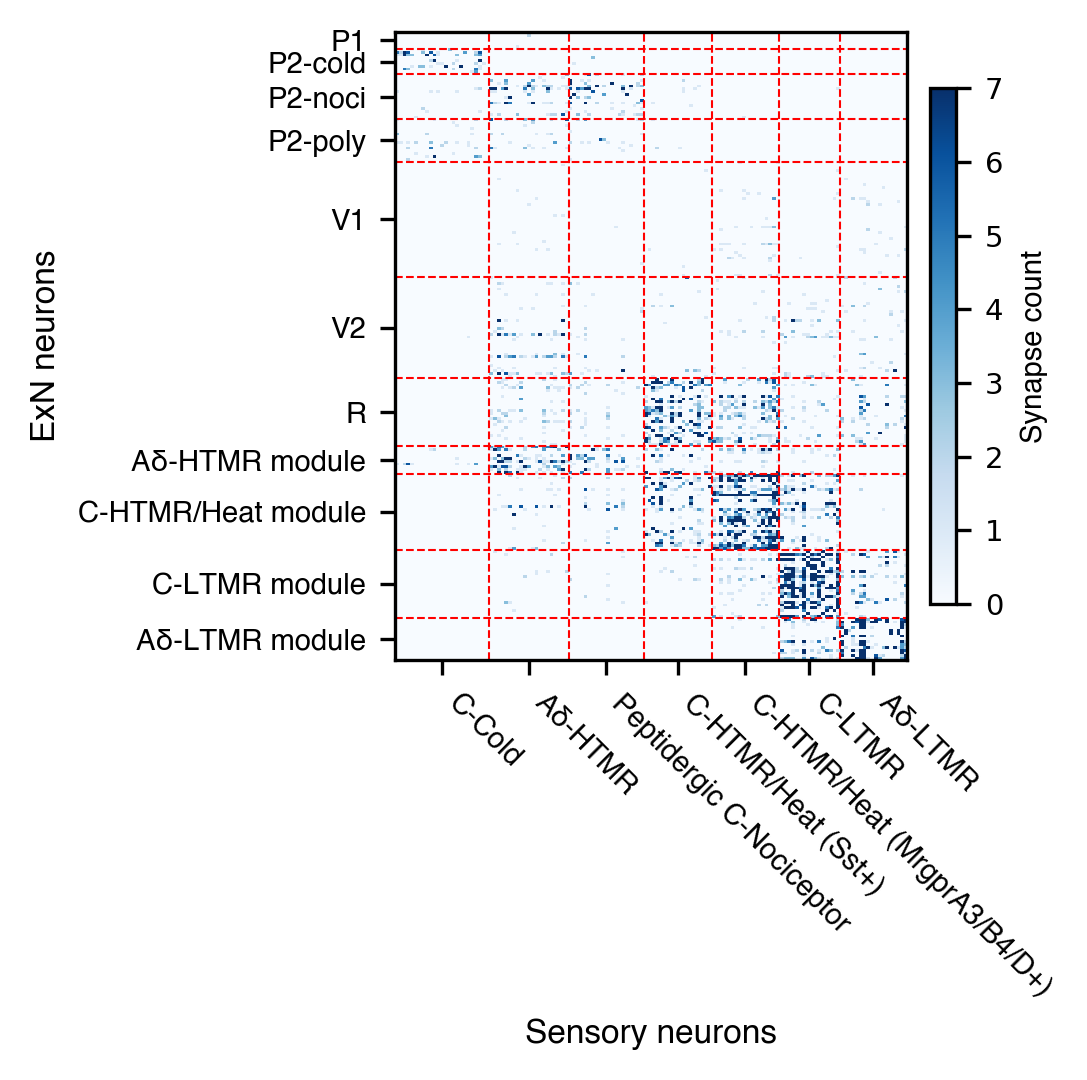

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# --------------------------------------------------
# Config
# --------------------------------------------------

out_dir = Path("sensory_exn_matrix")
out_dir.mkdir(exist_ok=True)

SAVE_FIG = True

FIG_NAME = (
    "sensory_to_exn_raw_connectivity_matrix.png"
)

CAP_PERCENTILE = 80


# --------------------------------------------------
# Display order
# --------------------------------------------------

sensory_order = [
    "C-Cold",
    "Aδ-HTMR",
    "Peptidergic C-Nociceptor",
    "C-HTMR/Heat (Sst+)",
    "C-HTMR/Heat (MrgprA3/B4/D+)",
    "C-LTMR",
    "Aδ-LTMR",
]


exn_order = [
    "P1",
    "P2-cold",
    "P2-noci",
    "P2-poly",
    "V1",
    "V2",
    "R",
    "Aδ-HTMR module",
    "C-HTMR/Heat module",
    "C-LTMR module",
    "Aδ-LTMR module",
]


SENSORY_LABEL_MAP = {
    "C-Cold": "C-Cold",
    "Aδ-HTMR": "Aδ-HTMR",
    "Peptidergic C-Nociceptor":
        "Peptidergic C-Nociceptor",
    "Aδ-LTMR": "Aδ-LTMR",
    "C-HTMR/Heat (MrgprA3/B4/D+)":
        "C-HTMR/Heat (MrgprA3/B4/D+)",
    "C-HTMR/Heat (Sst+)":
        "C-HTMR/Heat (Sst+)",
    "C-LTMR": "C-LTMR",
}


EXN_LABEL_MAP = {
    "P1": "P1",
    "P2-cold": "P2-cold",
    "P2-noci": "P2-noci",
    "P2-poly": "P2-poly",
    "V1": "V1",
    "V2": "V2",
    "R": "R",
    "C-HTMR/Heat module":
        "C-HTMR/Heat module",
    "C-LTMR module":
        "C-LTMR module",
    "Aδ-LTMR module":
        "Aδ-LTMR module",
    "Aδ-HTMR module":
        "Aδ-HTMR module",
}


# --------------------------------------------------
# Prepare matrix
# --------------------------------------------------

A_plot = A.copy()

A_plot.index = A_plot.index.astype(str)
A_plot.columns = A_plot.columns.astype(str)


# rows = ExN
# columns = sensory
A_plot = A_plot.T


# now rows sensory, cols ExN
# transpose back to desired orientation

A_plot = A.T


# ensure all neurons appear

A_plot = (
    A_plot
    .reindex(
        index=exn_label_map.index.astype(str),
        columns=sensory_label_map.index.astype(str),
    )
    .fillna(0)
)


# --------------------------------------------------
# Sorting helper
# --------------------------------------------------

def compute_sorted_ids_and_bounds(
    ids,
    label_map,
    cluster_order,
):

    ids = pd.Index(ids).astype(str)

    labels = (
        label_map
        .reindex(ids)
        .fillna("unknown")
    )


    order_df = pd.DataFrame(
        {
            "id": ids,
            "label": labels,
        }
    )


    order_df["label"] = pd.Categorical(
        order_df["label"],
        categories=cluster_order,
        ordered=True,
    )


    order_df = (
        order_df
        .sort_values(
            ["label", "id"],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )


    sorted_ids = order_df["id"].tolist()


    starts = []
    ends = []
    labels = []


    for label, group in order_df.groupby(
        "label",
        observed=True,
        sort=False,
    ):

        starts.append(group.index[0])
        ends.append(group.index[-1]+1)
        labels.append(label)


    centers = [
        (s+e-1)/2
        for s,e in zip(starts,ends)
    ]

    boundaries = [
        e-0.5
        for e in ends[:-1]
    ]


    return (
        sorted_ids,
        labels,
        centers,
        boundaries,
    )



# --------------------------------------------------
# Sort
# --------------------------------------------------

row_sorted, row_labels, row_centers, row_boundaries = (
    compute_sorted_ids_and_bounds(
        A_plot.index,
        exn_label_map,
        exn_order,
    )
)


col_sorted, col_labels, col_centers, col_boundaries = (
    compute_sorted_ids_and_bounds(
        A_plot.columns,
        sensory_label_map,
        sensory_order,
    )
)



A_sorted = (
    A_plot
    .reindex(
        index=row_sorted,
        columns=col_sorted,
    )
    .fillna(0)
)



# --------------------------------------------------
# Cap
# --------------------------------------------------

vals = A_sorted.values

positive = vals[
    vals > 0
]


vmax = np.percentile(
    positive,
    CAP_PERCENTILE
)


A_vis = np.clip(
    A_sorted.values,
    0,
    vmax,
)



# --------------------------------------------------
# Plot
# --------------------------------------------------

cm = 1/2.54

fig, ax = plt.subplots(
    figsize=(9*cm, 9*cm),
    dpi=300,
)


im = ax.imshow(
    A_vis,
    cmap="Blues",
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=vmax,
)



# ticks

ax.set_xticks(
    col_centers
)

ax.set_xticklabels(
    [
        SENSORY_LABEL_MAP.get(x,x)
        for x in col_labels
    ],
    rotation=-45,
    ha="left",
    fontsize=7,
    fontname="Helvetica",
)



ax.set_yticks(
    row_centers
)

ax.set_yticklabels(
    [
        EXN_LABEL_MAP.get(x,x)
        for x in row_labels
    ],
    fontsize=7,
    fontname="Helvetica",
)



# boundaries

for x in col_boundaries:
    ax.axvline(
        x,
        linestyle="--",
        color="red",
        linewidth=0.5,
    )


for y in row_boundaries:
    ax.axhline(
        y,
        linestyle="--",
        color="red",
        linewidth=0.5,
    )


ax.set_xlabel(
    "Sensory neurons",
    fontsize=8,
    fontname="Helvetica",
)

ax.set_ylabel(
    "ExN neurons",
    fontsize=8,
    fontname="Helvetica",
)



cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

cbar.set_label(
    "Synapse count",
    fontsize=7,
    fontname="Helvetica",
)

cbar.ax.tick_params(
    labelsize=7
)


plt.tight_layout()


if SAVE_FIG:
    plt.savefig(
        out_dir / FIG_NAME,
        bbox_inches="tight",
    )


plt.show()

In [70]:
import pandas as pd
import numpy as np


# --------------------------------------------------
# Load
# --------------------------------------------------

pn = pd.read_csv("/Users/wangchu/mesh_analysis/sensory_inputs/projection_neuron.csv")
exn = pd.read_csv("/Users/wangchu/mesh_analysis/sensory_inputs/excitatory_neurons.csv")


# --------------------------------------------------
# sensory input columns
# --------------------------------------------------

sensory_cols = [
    "Aδ-HTMR",
    "C-Cold",
    "C-HTMR",
    "C-HTMR-Non-peptidergic",
    "C-Heat",
    "Aβ-LTMR",
    "Aδ-LTMR",
    "C-LTMR",
    "low_confidence_sensory",
    "N/A"

]


# --------------------------------------------------
# Calculate neuron-level sensory fractions
# --------------------------------------------------

def calculate_sensory_fraction(df):

    frac_df = df.copy()

    total = (
        frac_df[sensory_cols]
        .sum(axis=1)
    )

    # avoid division by zero
    frac_df[sensory_cols] = (
        frac_df[sensory_cols]
        .div(total, axis=0)
    )

    return frac_df



pn_frac = calculate_sensory_fraction(pn)

exn_frac = calculate_sensory_fraction(exn)



# --------------------------------------------------
# Average by cell type
# --------------------------------------------------

def average_by_celltype(df):

    mean_matrix = (
        df
        .groupby("cell_type")[sensory_cols]
        .mean()
    )

    return mean_matrix



pn_type_fraction = average_by_celltype(
    pn_frac
)

exn_type_fraction = average_by_celltype(
    exn_frac
)


print("PN sensory fraction:")
display(pn_type_fraction)


print("ExN sensory fraction:")
display(exn_type_fraction)

PN sensory fraction:


,Aδ-HTMR,C-Cold,C-HTMR,C-HTMR-Non-peptidergic,C-Heat,Aβ-LTMR,Aδ-LTMR,C-LTMR,low_confidence_sensory,N/A
cell_type,,,,,,,,,,
p1,0.007716,0.011313,0.000690,0.000064,0.002948,0.000380,0.000203,0.000714,0.002801,0.973172
p2_cold,0.016457,0.351615,0.000708,0.000228,0.044788,0.000000,0.000000,0.000000,0.016244,0.569959
p2_noci,0.110897,0.013345,0.004532,0.001198,0.102460,0.000000,0.000000,0.000018,0.012957,0.754593
p2_poly,0.024654,0.038746,0.004791,0.005010,0.053422,0.000094,0.000028,0.001115,0.011542,0.860597


ExN sensory fraction:


,Aδ-HTMR,C-Cold,C-HTMR,C-HTMR-Non-peptidergic,C-Heat,Aβ-LTMR,Aδ-LTMR,C-LTMR,low_confidence_sensory,N/A
cell_type,,,,,,,,,,
adltmr_module,0.002293,0.000097,0.000194,0.000442,0.000176,0.012655,0.137102,0.022390,0.006349,0.818302
cltmr_module,0.003531,0.000293,0.001839,0.013320,0.004129,0.002277,0.006485,0.202106,0.011736,0.754284
noci_module,0.122003,0.017897,0.013578,0.023530,0.058706,0.002076,0.000000,0.003695,0.019527,0.738988
np_module,0.007396,0.000068,0.030555,0.239164,0.011226,0.000431,0.000393,0.026515,0.016654,0.667598
r,0.020831,0.000790,0.057557,0.053869,0.013040,0.005293,0.005495,0.010092,0.015396,0.817636
v1,0.007406,0.001065,0.000998,0.002903,0.002109,0.005061,0.001498,0.002551,0.003615,0.972795
v2,0.017826,0.000800,0.001920,0.002319,0.003698,0.008295,0.002030,0.005036,0.005267,0.952810


Sensory inputs >=25%


,target,sensory,fraction
0,P2-cold,C-Cold,0.351615
10,C-HTMR/Heat module,C-HTMR/Heat (MrgprA3/B4/D+),0.239164
11,C-LTMR module,C-LTMR,0.202106
12,Aδ-LTMR module,Aδ-LTMR,0.137102
8,Aδ-HTMR module,Aδ-HTMR,0.122003
2,P2-noci,Aδ-HTMR,0.110897
3,P2-noci,Peptidergic C-fibers,0.102460
9,Aδ-HTMR module,Peptidergic C-fibers,0.058706
6,R,C-HTMR/Heat (Sst+),0.057557
7,R,C-HTMR/Heat (MrgprA3/B4/D+),0.053869


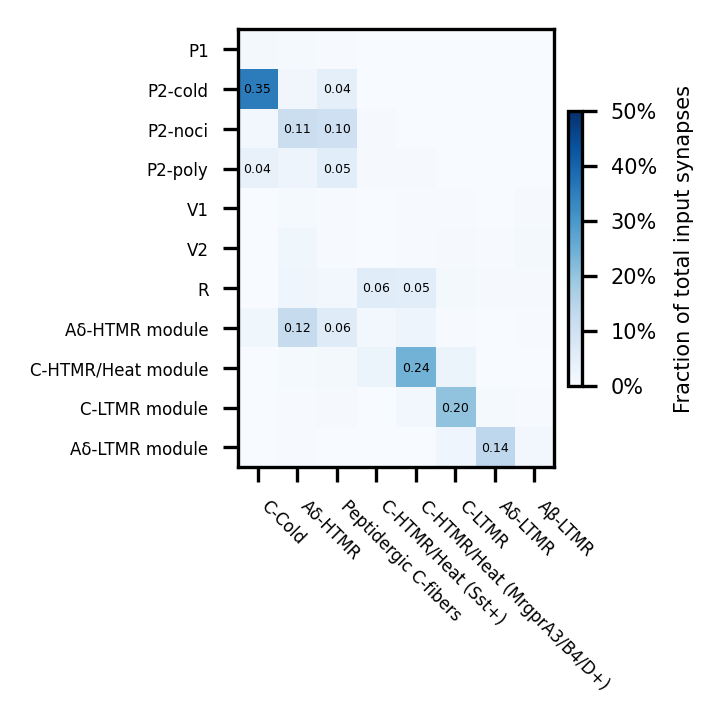

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==================================================
# Display remapping
# ==================================================

SENSORY_LABEL_MAP = {
    "C-Cold":
        "C-Cold",

    "Aδ-HTMR":
        "Aδ-HTMR",

    "C-HTMR":
        "C-HTMR/Heat (Sst+)",

    "C-HTMR-Non-peptidergic":
        "C-HTMR/Heat (MrgprA3/B4/D+)",

    "C-Heat":
        "Peptidergic C-fibers",

    "Aβ-LTMR":
        "Aβ-LTMR",

    "Aδ-LTMR":
        "Aδ-LTMR",

    "C-LTMR":
        "C-LTMR",
}


EXN_LABEL_MAP = {
    "p1":
        "P1",

    "p2_cold":
        "P2-cold",

    "p2_noci":
        "P2-noci",

    "p2_poly":
        "P2-poly",

    "v1":
        "V1",

    "v2":
        "V2",

    "r":
        "R",

    "noci_module":
        "Aδ-HTMR module",

    "np_module":
        "C-HTMR/Heat module",

    "cltmr_module":
        "C-LTMR module",

    "adltmr_module":
        "Aδ-LTMR module",
}



# ==================================================
# Internal order
# ==================================================

exn_order = [
    "p1",
    "p2_cold",
    "p2_noci",
    "p2_poly",
    "v1",
    "v2",
    "r",
    "noci_module",
    "np_module",
    "cltmr_module",
    "adltmr_module",
]


sensory_order = [
    "C-Cold",
    "Aδ-HTMR",
    "C-Heat",
    "C-HTMR",
    "C-HTMR-Non-peptidergic",
    "C-LTMR",
    "Aδ-LTMR",
    "Aβ-LTMR",
    
    
]



# ==================================================
# Combine PN + ExN
# ==================================================

combined_fraction = pd.concat(
    [
        pn_type_fraction,
        exn_type_fraction,
    ],
    axis=0,
)


# reorder
plot_df = combined_fraction.reindex(
    index=exn_order,
    columns=sensory_order,
)



# ==================================================
# Print dominant sensory inputs (>20%)
# ==================================================

threshold = 0.035

connections = []

for target in plot_df.index:

    for sensory in plot_df.columns:

        value = plot_df.loc[
            target,
            sensory
        ]

        if pd.notna(value) and value >= threshold:

            connections.append(
                {
                    "target":
                        EXN_LABEL_MAP.get(
                            target,
                            target
                        ),

                    "sensory":
                        SENSORY_LABEL_MAP.get(
                            sensory,
                            sensory
                        ),

                    "fraction":
                        value,
                }
            )


connections_df = pd.DataFrame(
    connections
).sort_values(
    "fraction",
    ascending=False
)


print(
    "Sensory inputs >=25%"
)

display(
    connections_df
)



# ==================================================
# Plot heatmap
# ==================================================

SAVE_FIG = True

SVG_PATH = (
    "sensory_input_fraction_by_celltype_0730.svg"
)



fig, ax = plt.subplots(
    figsize=(
        6/2.54,
        6/2.54
    ),
    dpi=300,
)



im = ax.imshow(
    plot_df.values,
    cmap="Blues",
    vmin=0,
    vmax=0.5,      # cap at 50%
    aspect="auto",
)



# x labels

ax.set_xticks(
    np.arange(
        len(plot_df.columns)
    )
)

ax.set_xticklabels(
    [
        SENSORY_LABEL_MAP.get(
            x,
            x
        )
        for x in plot_df.columns
    ],
    rotation=-45,
    ha="left",
    fontsize=4,
)



# y labels

ax.set_yticks(
    np.arange(
        len(plot_df.index)
    )
)

ax.set_yticklabels(
    [
        EXN_LABEL_MAP.get(
            x,
            x
        )
        for x in plot_df.index
    ],
    fontsize=4,
)



# annotate >20%

for i in range(
    plot_df.shape[0]
):

    for j in range(
        plot_df.shape[1]
    ):

        value = plot_df.iloc[i,j]

        if (
            pd.notna(value)
            and value >= threshold
        ):

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=3,
            )



# colorbar
# colorbar
cbar = plt.colorbar(
    im,
    ax=ax,
    fraction=0.04,
    pad=0.04,
)

cbar.set_label(
    "Fraction of total input synapses",
    fontsize=5,
)

# Show percentages from 0–50%
ticks = np.linspace(0, 0.5, 6)   # 0,10,20,30,40,50%
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{int(t*100)}%" for t in ticks])

cbar.ax.tick_params(
    labelsize=5
)



plt.tight_layout()



if SAVE_FIG:

    plt.savefig(
        SVG_PATH,
        bbox_inches="tight",
    )


plt.show()

In [78]:
import numpy as np
import pandas as pd


# ==================================================
# 1) Convert overlap matrices into long format
# ==================================================

density_df = pd.DataFrame({

    "pre": np.repeat(
        A_overlappairs_avg.index,
        len(A_overlappairs_avg.columns)
    ),

    "post": np.tile(
        A_overlappairs_avg.columns,
        len(A_overlappairs_avg.index)
    ),

    "avg_syn_per_overlap_pair":
        A_overlappairs_avg.to_numpy().ravel(),

    "density_syn_per_um":
        D_overlaponly_avg.to_numpy().ravel(),
})


density_df = density_df.dropna()



# ==================================================
# 2) Apply density threshold
# ==================================================

dens_thresh = 0.0036


density_df = density_df[
    density_df["density_syn_per_um"]
    >= dens_thresh
].copy()



# ==================================================
# 3) Match sensory proportion filtered connections
# ==================================================

# connections_df:
# target = ExN/PN
# sensory = sensory class

valid_pairs = connections_df[
    [
        "target",
        "sensory",
    ]
].copy()


valid_pairs.columns = [
    "post",
    "pre",
]


# merge
wiring_df = density_df.merge(
    valid_pairs,
    on=[
        "pre",
        "post",
    ],
    how="inner",
)



# ==================================================
# 4) Assign arrow size
# ==================================================

size_bins = (
    0.25,
    0.5,
    1,
    2,
    4,
    np.inf,
)


arrow_sizes_pts = (
    0.5,
    1,
    2,
    4,
    8,
)


size_idx = np.digitize(
    wiring_df[
        "avg_syn_per_overlap_pair"
    ],
    size_bins,
    right=False,
) - 1


size_idx = np.clip(
    size_idx,
    0,
    len(arrow_sizes_pts)-1,
)


wiring_df[
    "arrow_size_pts"
] = np.asarray(
    arrow_sizes_pts
)[size_idx]



# ==================================================
# 5) Assign density color bins
# ==================================================

BIN_TO_HEX = {

    0:
    "#c9ddf0",

    1:
    "#77b5d9",

    2:
    "#083e81",
}


color_bin_edges = (
    0.0036,
    0.007,
    0.014,
)


dens_idx = np.digitize(
    wiring_df[
        "density_syn_per_um"
    ],
    color_bin_edges,
    right=False,
) - 1


dens_idx = np.clip(
    dens_idx,
    0,
    2,
)


wiring_df[
    "dens_bin"
] = dens_idx


wiring_df[
    "color_hex"
] = [
    BIN_TO_HEX[int(x)]
    for x in dens_idx
]


wiring_df[
    "dens_bin_value"
] = (
    np.asarray(color_bin_edges)
    [dens_idx]
)



# ==================================================
# 6) Sort and display
# ==================================================

wiring_df = wiring_df.sort_values(
    [
        "post",
        "pre",
    ]
).reset_index(drop=True)



display(
    wiring_df[
        [
            "pre",
            "post",
            "avg_syn_per_overlap_pair",
            "density_syn_per_um",
            "arrow_size_pts",
            "dens_bin",
            "dens_bin_value",
            "color_hex",
        ]
    ]
)

,pre,post,avg_syn_per_overlap_pair,density_syn_per_um,arrow_size_pts,dens_bin,dens_bin_value,color_hex
0,Aδ-HTMR,Aδ-HTMR module,2.222892,0.022176,4.0,2,0.0140,#083e81
1,Peptidergic C-Nociceptor,Aδ-HTMR module,1.153846,0.009079,2.0,1,0.0070,#77b5d9
2,Aδ-LTMR,Aδ-LTMR module,10.793333,0.047481,8.0,2,0.0140,#083e81
3,C-HTMR/Heat (MrgprA3/B4/D+),C-HTMR/Heat module,6.080882,0.012380,8.0,1,0.0070,#77b5d9
4,C-LTMR,C-LTMR module,13.980519,0.017990,8.0,2,0.0140,#083e81
5,C-Cold,P2-cold,1.284672,0.008498,2.0,1,0.0070,#77b5d9
6,Aδ-HTMR,P2-noci,0.955801,0.012202,1.0,1,0.0070,#77b5d9
7,Peptidergic C-Nociceptor,P2-noci,1.368132,0.010121,2.0,1,0.0070,#77b5d9
8,C-Cold,P2-poly,0.292929,0.006547,0.5,0,0.0036,#c9ddf0
9,C-HTMR/Heat (Sst+),R,3.373913,0.012701,4.0,1,0.0070,#77b5d9


In [80]:
# ==================================================
# Rebuild complete anatomical table
# ==================================================

density_df = pd.DataFrame({

    "pre": np.repeat(
        A_overlappairs_avg.index,
        len(A_overlappairs_avg.columns)
    ),

    "post": np.tile(
        A_overlappairs_avg.columns,
        len(A_overlappairs_avg.index)
    ),

    "avg_syn_per_overlap_pair":
        A_overlappairs_avg.to_numpy().ravel(),

    "density_syn_per_um":
        D_overlaponly_avg.to_numpy().ravel(),
})


density_df = density_df.dropna()



# ==================================================
# Filter 1: sensory proportion >=25%
# ==================================================

filter1_pairs = (
    connections_df[
        connections_df["fraction"] >= 0.03
    ][
        ["target","sensory","fraction"]
    ]
    .rename(
        columns={
            "target":"post",
            "sensory":"pre"
        }
    )
)



# ==================================================
# Filter 2: anatomical
# ==================================================

filter2_pairs = density_df[
    (density_df["avg_syn_per_overlap_pair"] > 0.25) &
    (density_df["density_syn_per_um"] > 0.0036)
].copy()



# ==================================================
# Make pair keys
# ==================================================

f1_keys = set(
    zip(
        filter1_pairs["pre"],
        filter1_pairs["post"]
    )
)


f2_keys = set(
    zip(
        filter2_pairs["pre"],
        filter2_pairs["post"]
    )
)



# ==================================================
# Three groups
# ==================================================

both_keys = f1_keys & f2_keys

filter1_only_keys = f1_keys - f2_keys

filter2_only_keys = f2_keys - f1_keys



# ==================================================
# 1. Both filters
# ==================================================

df_both = density_df[
    density_df.apply(
        lambda x:
        (x["pre"],x["post"]) in both_keys,
        axis=1
    )
].copy()



# add sensory fraction

df_both = df_both.merge(
    filter1_pairs,
    on=["pre","post"],
    how="left"
)



# ==================================================
# 2. Only filter 1
# ==================================================

df_filter1_only = density_df[
    density_df.apply(
        lambda x:
        (x["pre"],x["post"]) in filter1_only_keys,
        axis=1
    )
].copy()


df_filter1_only = df_filter1_only.merge(
    filter1_pairs,
    on=["pre","post"],
    how="left"
)



# ==================================================
# 3. Only filter 2
# ==================================================

df_filter2_only = density_df[
    density_df.apply(
        lambda x:
        (x["pre"],x["post"]) in filter2_only_keys,
        axis=1
    )
].copy()



# ==================================================
# Arrow size
# ==================================================

def add_arrow_properties(df):

    df=df.copy()

    size_idx = np.digitize(
        df["avg_syn_per_overlap_pair"],
        size_bins,
        right=False
    )-1


    size_idx=np.clip(
        size_idx,
        0,
        len(arrow_sizes_pts)-1
    )


    df["arrow_size_pts"] = np.asarray(
        arrow_sizes_pts
    )[size_idx]


    dens_idx=np.digitize(
        df["density_syn_per_um"],
        color_bin_edges,
        right=False
    )-1


    dens_idx=np.clip(
        dens_idx,
        0,
        2
    )


    df["color_hex"] = (
        pd.Series(dens_idx,index=df.index)
        .map(BIN_TO_HEX)
    )


    return df



df_both = add_arrow_properties(df_both)

df_filter1_only = add_arrow_properties(df_filter1_only)

df_filter2_only = add_arrow_properties(df_filter2_only)



# ==================================================
# ==================================================
# Display three filtering categories
# ==================================================
print("DF1: Connections passing both filters")
print("    Filter 1: sensory input fraction >= 3.5% total syn")
print("    Filter 2: avg_syn_per_overlap_pair > 0.25 and density_syn_per_um > 0.0036")

display(
    df_both[
        [
            "pre",
            "post",
            "fraction",
            "avg_syn_per_overlap_pair",
            "density_syn_per_um",
            "arrow_size_pts",
            "color_hex"
        ]
    ]
)


print("\nDF2: Connections passing sensory proportion filter only")
print("    Filter 1: sensory input fraction >= 3.5% total syn")
print("    Failed Filter 2: avg_syn_per_overlap_pair <= 0.25 or density_syn_per_um <= 0.0036")

display(
    df_filter1_only[
        [
            "pre",
            "post",
            "fraction",
            "avg_syn_per_overlap_pair",
            "density_syn_per_um",
            "arrow_size_pts",
            "color_hex"
        ]
    ]
)


print("\nDF3: Connections passing anatomical filter only")
print("    Filter 2: avg_syn_per_overlap_pair > 0.25 and density_syn_per_um > 0.0036")
print("    Failed Filter 1: Filter 1: sensory input fraction >= 3.5% total syn")

display(
    df_filter2_only[
        [
            "pre",
            "post",
            "avg_syn_per_overlap_pair",
            "density_syn_per_um",
            "arrow_size_pts",
            "color_hex"
        ]
    ]
)

DF1: Connections passing both filters
    Filter 1: sensory input fraction >= 3.5% total syn
    Filter 2: avg_syn_per_overlap_pair > 0.25 and density_syn_per_um > 0.0036


,pre,post,fraction,avg_syn_per_overlap_pair,density_syn_per_um,arrow_size_pts,color_hex
0,C-Cold,P2-cold,0.351615,1.284672,0.008498,2.0,#77b5d9
1,C-Cold,P2-poly,0.038746,0.292929,0.006547,0.5,#c9ddf0
2,Aδ-HTMR,P2-noci,0.110897,0.955801,0.012202,1.0,#77b5d9
3,Aδ-HTMR,Aδ-HTMR module,0.122003,2.222892,0.022176,4.0,#083e81
4,Peptidergic C-Nociceptor,P2-noci,0.102460,1.368132,0.010121,2.0,#77b5d9
5,Peptidergic C-Nociceptor,Aδ-HTMR module,0.058706,1.153846,0.009079,2.0,#77b5d9
6,Aδ-LTMR,Aδ-LTMR module,0.137102,10.793333,0.047481,8.0,#083e81
7,C-HTMR/Heat (MrgprA3/B4/D+),C-HTMR/Heat module,0.239164,6.080882,0.012380,8.0,#77b5d9
8,C-HTMR/Heat (Sst+),R,0.057557,3.373913,0.012701,4.0,#77b5d9
9,C-LTMR,C-LTMR module,0.202106,13.980519,0.017990,8.0,#083e81



DF2: Connections passing sensory proportion filter only
    Filter 1: sensory input fraction >= 3.5% total syn
    Failed Filter 2: avg_syn_per_overlap_pair <= 0.25 or density_syn_per_um <= 0.0036


,pre,post,fraction,avg_syn_per_overlap_pair,density_syn_per_um,arrow_size_pts,color_hex
0,Peptidergic C-Nociceptor,P2-cold,0.044788,0.050633,0.001047,0.5,#c9ddf0
1,Peptidergic C-Nociceptor,P2-poly,0.053422,0.240000,0.003423,0.5,#c9ddf0
2,C-HTMR/Heat (MrgprA3/B4/D+),R,0.053869,1.126404,0.002317,2.0,#c9ddf0



DF3: Connections passing anatomical filter only
    Filter 2: avg_syn_per_overlap_pair > 0.25 and density_syn_per_um > 0.0036
    Failed Filter 1: Filter 1: sensory input fraction >= 3.5% total syn


,pre,post,avg_syn_per_overlap_pair,density_syn_per_um,arrow_size_pts,color_hex
10,C-Cold,Aδ-HTMR module,0.307692,0.004619,0.5,#c9ddf0
14,Aδ-HTMR,P2-poly,0.441667,0.009639,0.5,#77b5d9
16,Aδ-HTMR,V2,0.475845,0.005133,0.5,#c9ddf0
17,Aδ-HTMR,R,0.309677,0.005064,0.5,#c9ddf0
18,Aδ-HTMR,C-HTMR/Heat module,0.259690,0.004863,0.5,#c9ddf0
28,Peptidergic C-Nociceptor,R,0.294118,0.003637,0.5,#c9ddf0
29,Peptidergic C-Nociceptor,C-HTMR/Heat module,0.610526,0.012450,1.0,#77b5d9
39,Aδ-LTMR,R,1.122137,0.017640,2.0,#083e81
41,Aδ-LTMR,C-LTMR module,0.962441,0.005002,1.0,#c9ddf0
62,C-HTMR/Heat (Sst+),C-HTMR/Heat module,1.831081,0.011405,2.0,#77b5d9
